In [ ]:
data_path = '/content/drive/MyDrive/UTY/Semester 7/Pemrosesan Teks /Mini Project/cod_reviews_clean.csv'

# Load Data


In [ ]:
import pandas as pd

df = pd.read_csv(data_path)
df.head()

,userName,content,score,content_clean
0,Pengguna Google,"Call of duty pleaseeee my lucky draw, i want d...",5,"call of duty pleaseeee my lucky draw, i want d..."
1,Pengguna Google,keren,5,keren
2,Pengguna Google,"bagus,tapi aku gak tau kenapa suka keluar send...",5,"bagus,tapi aku gak tau kenapa suka keluar send..."
3,Pengguna Google,ni gem udah sepin dl q33 holidays eda dapat da...,2,ni gem udah sepin dl q33 holidays eda dapat da...
4,Pengguna Google,Tolong kalau sering update jangan sampai mengh...,5,tolong kalau sering update jangan sampai mengh...


# Preprocessing

## Perform Stemming



In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    if not isinstance(text, str):
        return text
    # Stemming also usually involves lowercasing, though our text is already lowercased
    return stemmer.stem(text)

df['stemmed'] = df['content_clean'].apply(stem_text)

## Remove Numbers and Punctuation



In [ ]:
import string

def remove_numbers_punctuation(text):
    if not isinstance(text, str): # Handle non-string types, e.g., if there are NaNs
        return text
    # Remove numbers
    text = ''.join([char for char in text if not char.isdigit()])
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['content_clean'] = df['stemmed'].apply(remove_numbers_punctuation)

## Remove Emojis




In [ ]:
import re

def remove_emojis(text):
    if not isinstance(text, str):
        return text
    # Comprehensive regex pattern for various emoji blocks
    emoji_pattern = re.compile(
        "[" # Start of character set
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"  # Dingbats
        "\U000024C2-\U0001F251"  # Enclosed CJK Letters and Months, Ideographic Variation Selectors, Mahjong Tiles, Playing Cards, Enclosed Alphanumeric Supplement, Enclosed Ideographic Supplement, CJK Unified Ideographs Extension A, CJK Compatibility Ideographs
        "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        "\U0001FA00-\U0001FA6F"  # Chess Symbols
        "\U00002B50" # Star
        "\U00002B06-\U00002B07" # Arrows
        "\U00002934-\U00002935" # Arrows
        "\U00002B55" # Large Circle
        "\U0000303D" # Part Alternation Mark
        "\U0000A97C" # Right Curly Bracket
        "\U0000A97F" # Curly Bracket
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

df['content_clean'] = df['content_clean'].apply(remove_emojis)

## Normalize Typos and Slang Words



In [ ]:
typo_slang_map = {
    'pleaseeee': 'please',
    'pengen': 'ingin',
    'blg': 'bilang',
    'udh': 'sudah',
    'ga': 'tidak',
    'gpp': 'tidak apa apa',
    'gk': 'tidak',
    'bgt': 'banget',
    'kaga': 'tidak',
    'bgus': 'bagus',
    'bgs': 'bagus',
    'maen': 'main',
    'cpet': 'cepat',
    'bikin': 'membuat',
    'klo': 'kalau',
    'yg': 'yang',
    'gmn': 'bagaimana',
    'pke': 'pakai',
    'hp': 'handphone',
    'ngebug': 'bug',
    'udh': 'sudah',
    'jd': 'jadi',
    'nya': '',
    'cod': 'call of duty',
    'dl': 'dulu',
    'q33': 'game',
    'eda': 'tidak',
    'dpt': 'dapat',
    'nih': 'ini',
    'gak': 'tidak',
    'bagu': 'bagus',
    'tpi': 'tapi',
    'trus': 'terus',
    'teru': 'terus',
    'jaring': 'jaringan', 'ngelagg': 'ngelag', 'beratt': 'berat',
    'gem': 'game',
    'good': 'bagus', 'trabaik': 'terbaik', 'ookk': 'oke', 'trbaik': 'terbaik', 'ok': 'oke',
    'cras': 'crash',
    'knok': 'knock', 'ngeleg': 'ngelag',
    'akupenuh': 'penuh',
    'mantab': 'mantap',
    'kaluar': 'keluar',
    'habisa': 'gabisa',
    'terngangu': 'terganggu',
    'anjig': 'anj', 'ajg': 'anj',
    'kontl': 'kntl', 'kontoo': 'kntl',
    'jelekk': 'jelek', 'updat': 'update', 'mls': 'malas'
}

def normalize_typos_slang(text):
    if not isinstance(text, str):
        return text
    # Convert text to lowercase to match dictionary keys
    text_lower = text.lower()
    words = text_lower.split()
    normalized_words = []
    for word in words:
        if word in typo_slang_map:
            normalized_words.append(typo_slang_map[word])
        else:
            normalized_words.append(word)
    return ' '.join(normalized_words)

df['preprocessed'] = df['content_clean'].apply(normalize_typos_slang)

## Remove Stopwords


In [ ]:
import nltk
from nltk.corpus import stopwords

stop_words = set([
    'yang', 'nya', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'pada', 'adalah', 'itu', 'aja', 'tapi', 'sih', 'tiap', 'saat', 'tapi', 'dulu', 'ini', 'saya',
    'kami', 'kita', 'anda', 'mereka', 'atau', 'juga', 'yah', 'ya', 'nah', 'kok', 'karena', 'agar', 'supaya', 'sebagai', 'oleh', 'terhadap', 'tentang', 'bahwa', 'saja',
    'ada', 'aku', 'kalau', 'apa', 'call', 'duty', 'lah', 'codm', 'gua', 'kali', 'garena', 'kan', 'game', 'main', 'lagi', 'jadi'
])

def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    words = text.lower().split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

df['preprocessed'] = df['preprocessed'].apply(remove_stopwords)

## Remove Short Words



In [ ]:
def remove_short_words(text):
    if not isinstance(text, str):
        return text
    words = text.split()
    filtered_words = [word for word in words if len(word) >= 3]
    return ' '.join(filtered_words)

df['preprocessed'] = df['preprocessed'].apply(remove_short_words)

## Remove Repeated Characters



In [ ]:
import re

def remove_repeated_chars(text):
    if not isinstance(text, str):
        return text
    # Regex to find any character repeated more than twice
    # For example, 'aaaa' becomes 'aa'
    pattern = re.compile(r'(.)\1{2,}')
    return pattern.sub(r'\1\1', text)

df['preprocessed'] = df['preprocessed'].apply(remove_repeated_chars)

# Label Data with Sentiment


In [ ]:
def get_sentiment(score):
    if score in [1, 2]:
        return 'negatif'
    elif score == 3:
        return 'netral'
    elif score in [4, 5]:
        return 'positif'
    else:
        return None # Handle potential unexpected scores

df['sentiment'] = df['score'].apply(get_sentiment)

# Lexicon Validation

In [ ]:
lexicon_positive = [
    'baik', 'bagus', 'senang', 'puas', 'mantap', 'hebat', 'cepat', 'mudah', 'ramah', 'oke', ''
    'nyaman', 'keren', 'suka', 'seru', 'terbaik', 'skin', 'keren', 'hadiah'
]

lexicon_negative = [
    'buruk', 'jelek', 'kecewa', 'lambat', 'sulit', 'error', 'parah', 'hapus', 'berat', 'asu', 'hilang', 'gabisa', 'ga', 'tidak', 'bosan', 'uinstall'
    'mahal', 'lemot', 'benci', 'gagal', 'ngeselin', 'bug', 'kikir', 'keluar', 'stuck', 'bye', 'bot', 'ilang', 'mati', 'beban', 'ampas', 'under',
    'burik', 'crash', 'knock', 'nguras', 'bayar', 'tolol', 'gajelas', 'hancur', 'peras', 'afk', 'tuli', 'drop', 'depresi', 'matane', 'cok',
    'pisah', 'malas', 'kurang', 'penuh', 'tutup', 'binatang', 'bukan', 'tolong', 'nerf', 'aneh', 'kecil', 'busuk', 'terganggu', 'susah', 'kntl',
    'anj', 'lama', 'rusak', 'stuck', 'yatim', 'badmood', 'sampah', 'sepi', 'masalah', 'cape', 'maling', 'ngelag', 'lag', 'mulu', 'bodoh', 'manja',
    'eek', 'cacat', 'kalah', 'pelit', 'frame', 'drop', 'heran', 'rugi'
]

In [ ]:
def lexicon_sentiment(text):
    score = 0
    words = text.split()

    for word in words:
        if word in lexicon_positive:
            score += 1
        elif word in lexicon_negative:
            score -= 1

    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

In [ ]:
df["lexicon"] = df['preprocessed'].astype(str).apply(lexicon_sentiment)

df.to_csv('clean.csv', index = False)

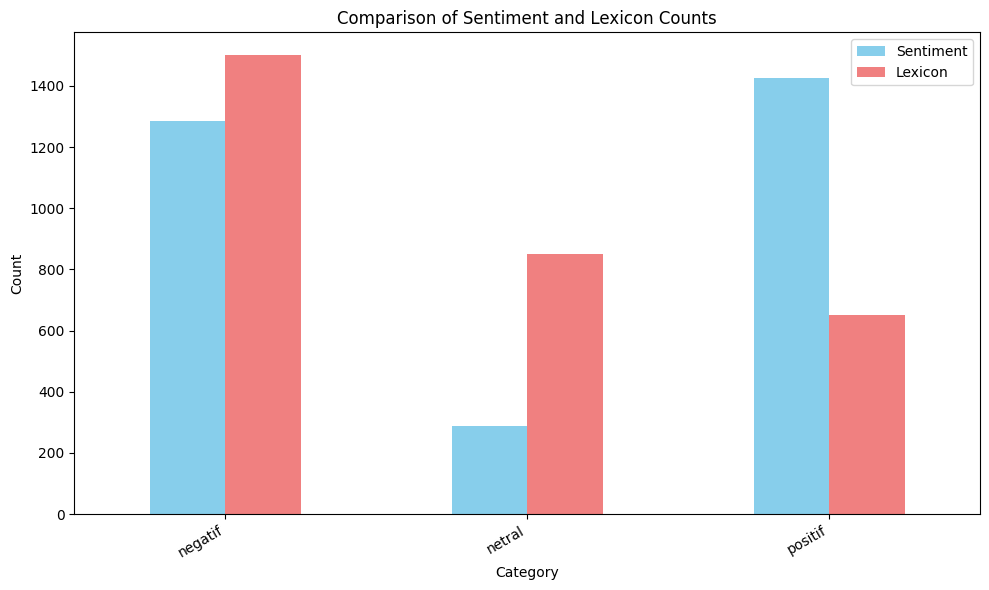

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate counts for 'sentiment' column
sentiment_counts = df['sentiment'].value_counts()

# Calculate counts for 'lexicon' column
lexicon_counts = df['lexicon'].value_counts()

# Combine counts into a single DataFrame for comparison
comparison_df = pd.DataFrame({'Sentiment': sentiment_counts, 'Lexicon': lexicon_counts})

# Plotting the bar chart
comparison_df.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Comparison of Sentiment and Lexicon Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
print(f"Shape of DataFrame before removal: {df.shape}")

# Identify rows where sentiment and lexicon are not synchronized for positive/negative
condition_to_remove = (
    (df['sentiment'] == 'positif') & (df['lexicon'] != 'positif')
) | (
    (df['sentiment'] == 'negatif') & (df['lexicon'] != 'negatif')
)

# Get the indices of rows to drop
rows_to_drop = df[condition_to_remove].index

# Drop the rows from the DataFrame
df_cleaned = df.drop(rows_to_drop)

print(f"Shape of DataFrame after removal: {df_cleaned.shape}")

Shape of DataFrame before removal: (3000, 8)
Shape of DataFrame after removal: (1809, 8)


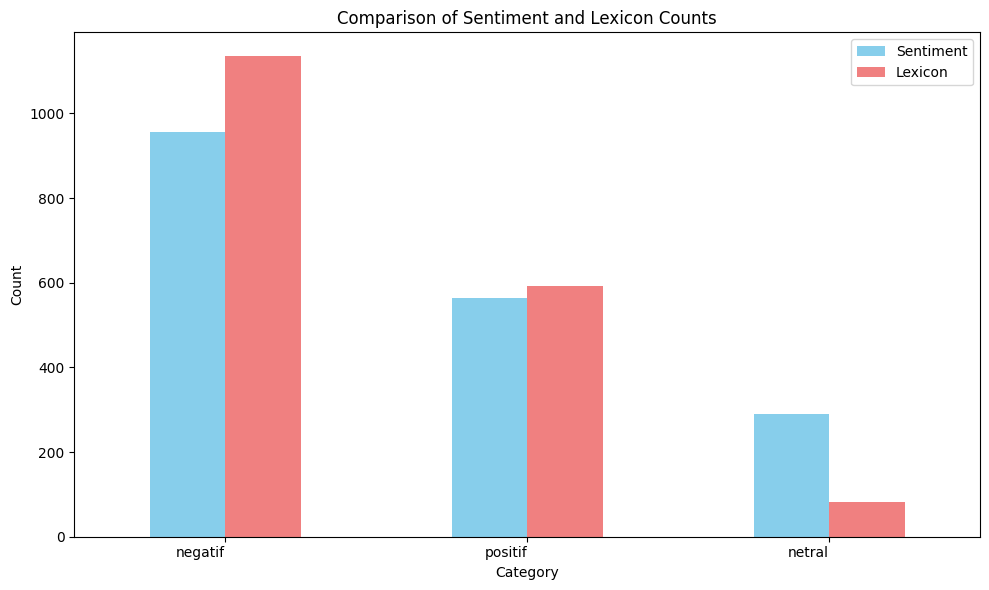

In [ ]:
# Calculate counts for 'sentiment' column
sentiment_counts = df_cleaned['sentiment'].value_counts()

# Calculate counts for 'lexicon' column
lexicon_counts = df_cleaned['lexicon'].value_counts()

# Combine counts into a single DataFrame for comparison
comparison_df_cleaned = pd.DataFrame({'Sentiment': sentiment_counts, 'Lexicon': lexicon_counts})

# Plotting the bar chart
comparison_df_cleaned.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])
plt.title('Comparison of Sentiment and Lexicon Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

# Visualization

## Visualize Positive Sentiment




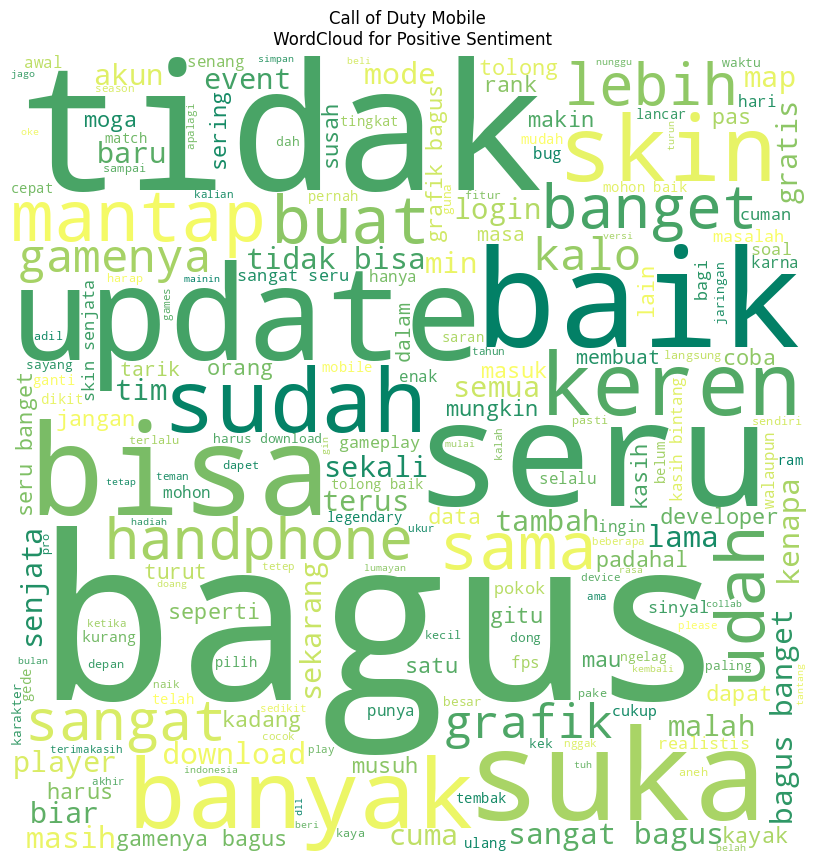

In [ ]:
df_positive = df[df['lexicon'] == 'positif']

# Concatenate all preprocessed text for WordCloud
all_positive_text = " ".join(df_positive['preprocessed'].fillna('').astype(str))

# Generate and display WordCloud for positive sentiment
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white', colormap = 'summer',
                min_font_size = 10).generate(all_positive_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.title('Call of Duty Mobile \n WordCloud for Positive Sentiment')
plt.show()

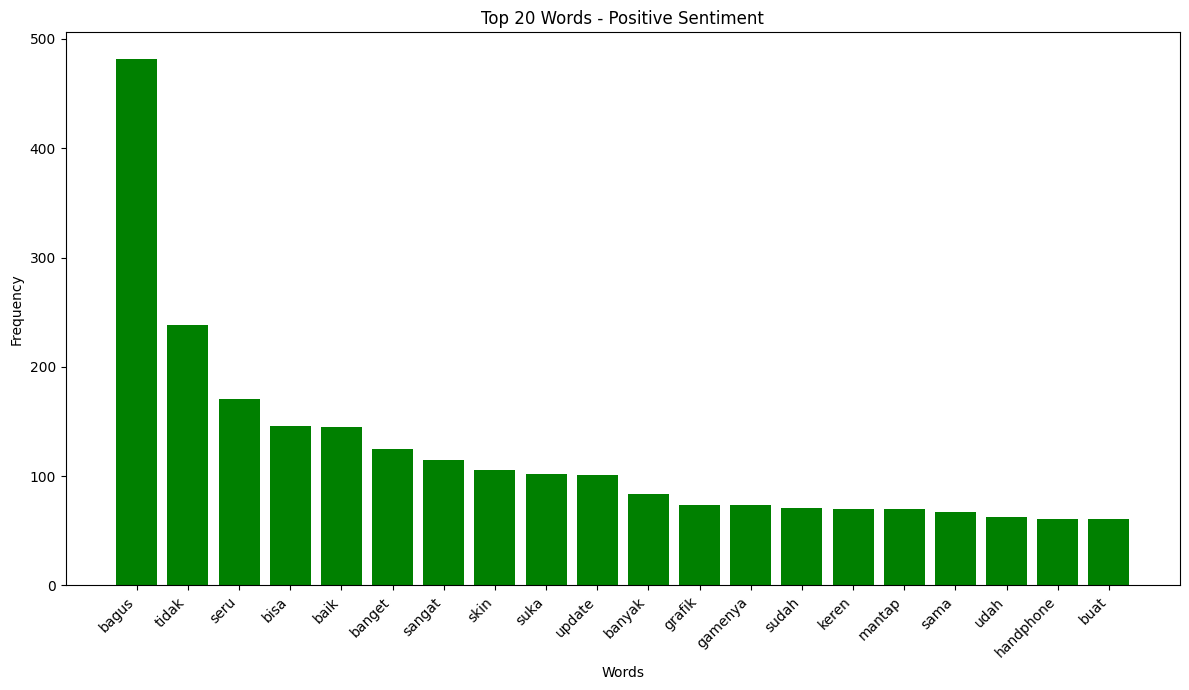

In [ ]:
import collections
import matplotlib.pyplot as plt

# Collect all words from the 'preprocessed' column for positive sentiment
positive_words = []
for text in df_positive['preprocessed'].fillna('').astype(str):
    positive_words.extend(text.split())

# Count the frequency of each word
word_counts = collections.Counter(positive_words)

# Get the top 20 most frequent words
top_20_words = word_counts.most_common(20)

# Prepare data for the bar chart
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

# Create the bar chart
plt.figure(figsize=(12, 7))
plt.bar(words, counts, color='green')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Words - Positive Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualize Neutral Sentiment

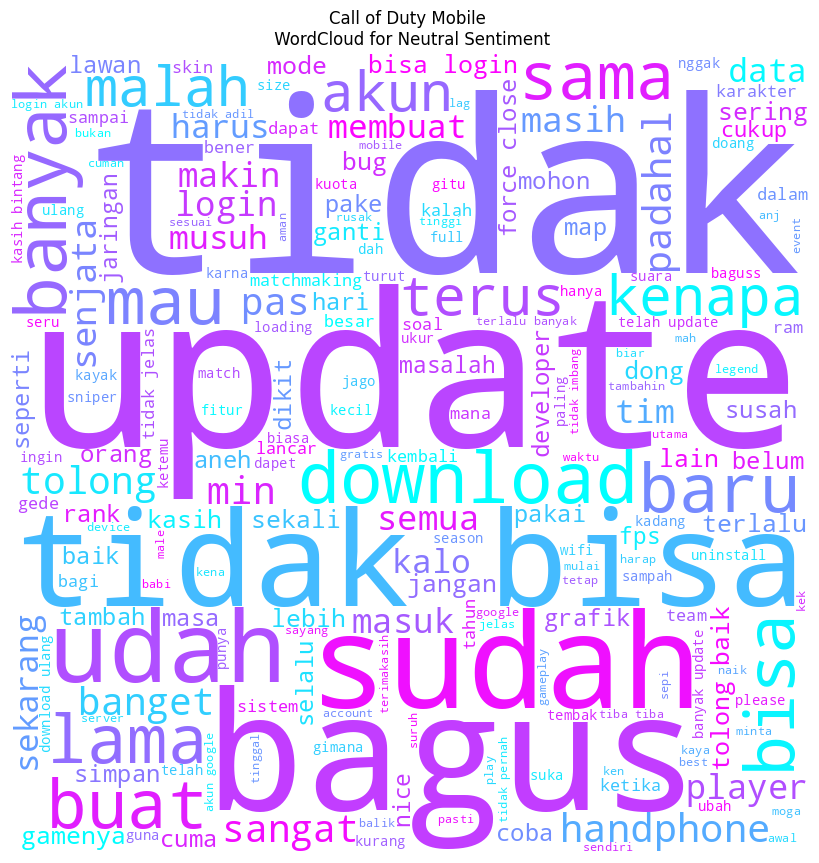

In [ ]:
df_neutral = df[df['lexicon'] == 'netral']

# Concatenate all preprocessed text for WordCloud
all_neutral_text = " ".join(df_neutral['preprocessed'].fillna('').astype(str))

# Generate and display WordCloud for neutral sentiment
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white', colormap = 'cool',
                min_font_size = 10).generate(all_neutral_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.title('Call of Duty Mobile \n WordCloud for Neutral Sentiment')
plt.show()

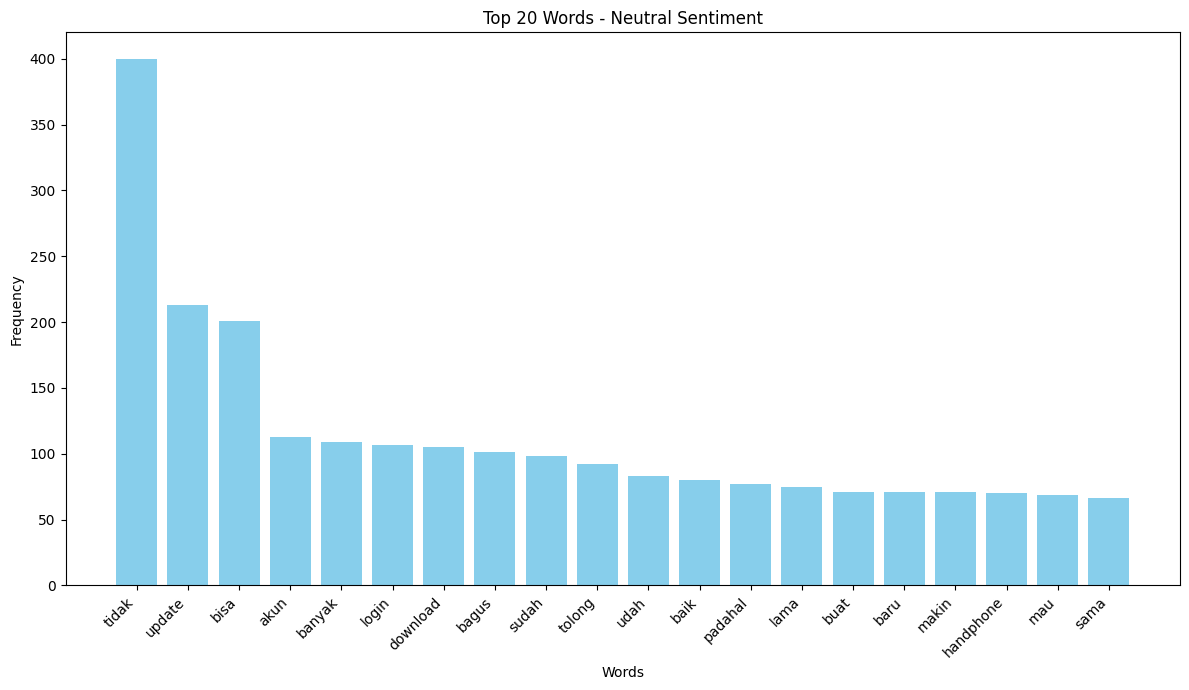

In [ ]:
import collections
import matplotlib.pyplot as plt

# Collect all words from the 'preprocessed' column for neutral sentiment
neutral_words = []
for text in df_neutral['preprocessed'].fillna('').astype(str):
    neutral_words.extend(text.split())

# Count the frequency of each word
word_counts_neutral = collections.Counter(neutral_words)

# Get the top 20 most frequent words
top_20_words_neutral = word_counts_neutral.most_common(20)

# Prepare data for the bar chart
words_neutral = [word for word, count in top_20_words_neutral]
counts_neutral = [count for word, count in top_20_words_neutral]

# Create the bar chart
plt.figure(figsize=(12, 7))
plt.bar(words_neutral, counts_neutral, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Words - Neutral Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Visualize Negative Sentiment

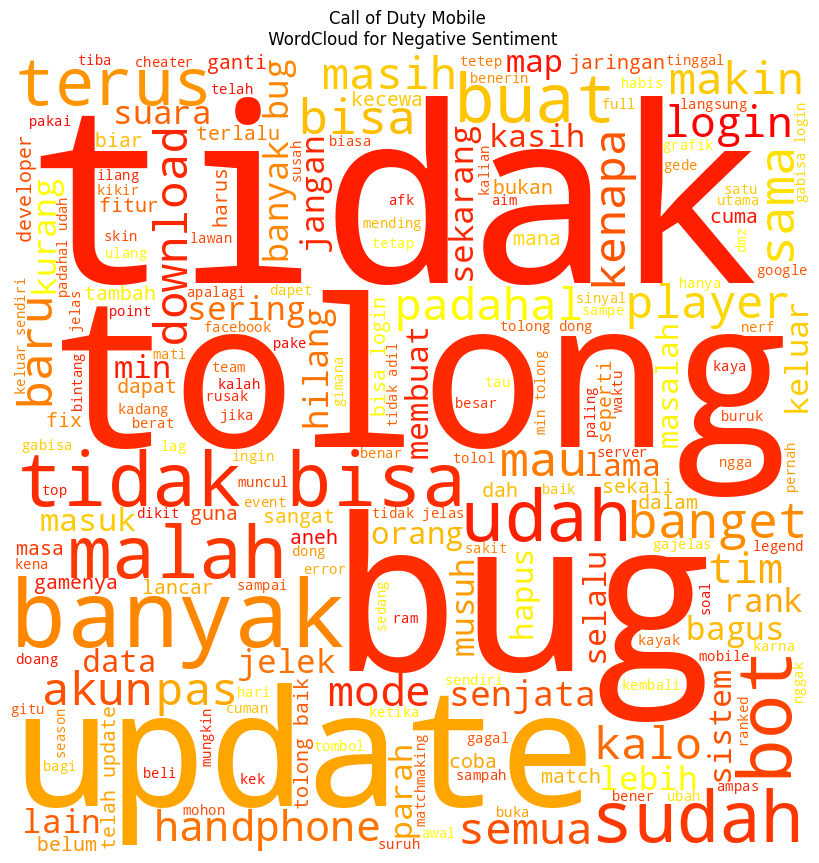

In [ ]:
df_negative = df[df['lexicon'] == 'negatif']

# Concatenate all preprocessed text for WordCloud
all_negative_text = " ".join(df_negative['preprocessed'].fillna('').astype(str))

# Generate and display WordCloud for negative sentiment
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white', colormap = 'autumn',
                min_font_size = 10).generate(all_negative_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.title('Call of Duty Mobile \n WordCloud for Negative Sentiment')
plt.show()

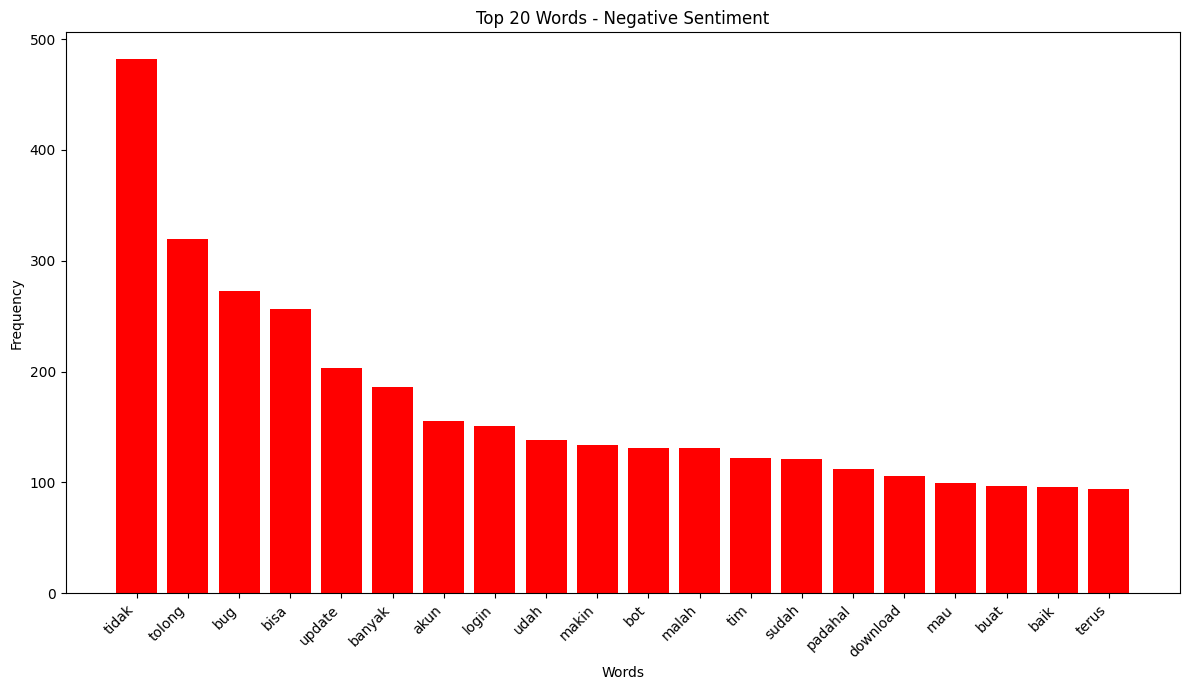

In [ ]:
import collections
import matplotlib.pyplot as plt

# Collect all words from the 'preprocessed' column for negative sentiment
negative_words = []
for text in df_negative['preprocessed'].fillna('').astype(str):
    negative_words.extend(text.split())

# Count the frequency of each word
word_counts_negative = collections.Counter(negative_words)

# Get the top 20 most frequent words
top_20_words_negative = word_counts_negative.most_common(20)

# Prepare data for the bar chart
words_negative = [word for word, count in top_20_words_negative]
counts_negative = [count for word, count in top_20_words_negative]

# Create the bar chart
plt.figure(figsize=(12, 7))
plt.bar(words_negative, counts_negative, color='red')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Words - Negative Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task
Generate bigrams, trigrams, and 4-grams from the 'preprocessed' column for each sentiment ('positif', 'netral', 'negatif') in the `df_cleaned` DataFrame, and then create bar charts to visualize the top N-grams for each sentiment, distinguishing them by sentiment in the plot titles and using appropriate colors.

## Generate N-grams for each sentiment

### Subtask:
Generate bigrams, trigrams, and 4-grams from the 'preprocessed' column for each sentiment ('positif', 'netral', 'negatif') present in the 'lexicon' column.


**Reasoning**:
The first step is to import the necessary libraries and define the `generate_ngrams` function as described in the instructions. This function will be used later to create bigrams, trigrams, and 4-grams.



In [ ]:
from nltk.util import ngrams
from collections import Counter
import pandas as pd

def generate_ngrams(text_list, n):
    # Join the words into a single string, then split to handle potential multiple spaces
    # and ensure consistent tokenization.
    all_words = []
    for text in text_list:
        if isinstance(text, str):
            all_words.extend(text.split())

    # Generate n-grams
    n_grams = ngrams(all_words, n)

    # Count the frequency of each n-gram
    return Counter(n_grams)

print("N-gram generation function defined.")

N-gram generation function defined.


**Reasoning**:
Filter the `df_cleaned` DataFrame to create three new DataFrames: `df_positive_cleaned`, `df_neutral_cleaned`, and `df_negative_cleaned` based on the 'lexicon' column, as specified in the instructions. This prepares the data for N-gram generation for each sentiment.



In [ ]:
df_positive_cleaned = df_cleaned[df_cleaned['lexicon'] == 'positif']
df_neutral_cleaned = df_cleaned[df_cleaned['lexicon'] == 'netral']
df_negative_cleaned = df_cleaned[df_cleaned['lexicon'] == 'negatif']

print(f"Shape of df_positive_cleaned: {df_positive_cleaned.shape}")
print(f"Shape of df_neutral_cleaned: {df_neutral_cleaned.shape}")
print(f"Shape of df_negative_cleaned: {df_negative_cleaned.shape}")

Shape of df_positive_cleaned: (666, 8)
Shape of df_neutral_cleaned: (132, 8)
Shape of df_negative_cleaned: (722, 8)


**Reasoning**:
Now that the dataframes are filtered by sentiment, the next step is to concatenate the 'preprocessed' text for each sentiment and apply the `generate_ngrams` function to create bigrams, trigrams, and 4-grams as per the instructions. This will prepare the N-gram data for further analysis and visualization.



In [ ]:
import itertools

# Concatenate all preprocessed text for each sentiment
all_positive_text_list = df_positive_cleaned['preprocessed'].fillna('').astype(str).tolist()
all_neutral_text_list = df_neutral_cleaned['preprocessed'].fillna('').astype(str).tolist()
all_negative_text_list = df_negative_cleaned['preprocessed'].fillna('').astype(str).tolist()

# Generate N-grams for each sentiment

# Positive sentiment
positive_bigrams = generate_ngrams(all_positive_text_list, 2)
positive_trigrams = generate_ngrams(all_positive_text_list, 3)
positive_4grams = generate_ngrams(all_positive_text_list, 4)

# Neutral sentiment
neutral_bigrams = generate_ngrams(all_neutral_text_list, 2)
neutral_trigrams = generate_ngrams(all_neutral_text_list, 3)
neutral_4grams = generate_ngrams(all_neutral_text_list, 4)

# Negative sentiment
negative_bigrams = generate_ngrams(all_negative_text_list, 2)
negative_trigrams = generate_ngrams(all_negative_text_list, 3)
negative_4grams = generate_ngrams(all_negative_text_list, 4)

print("N-grams generated for all sentiments.")

N-grams generated for all sentiments.


Generating plots for Positive Sentiment...


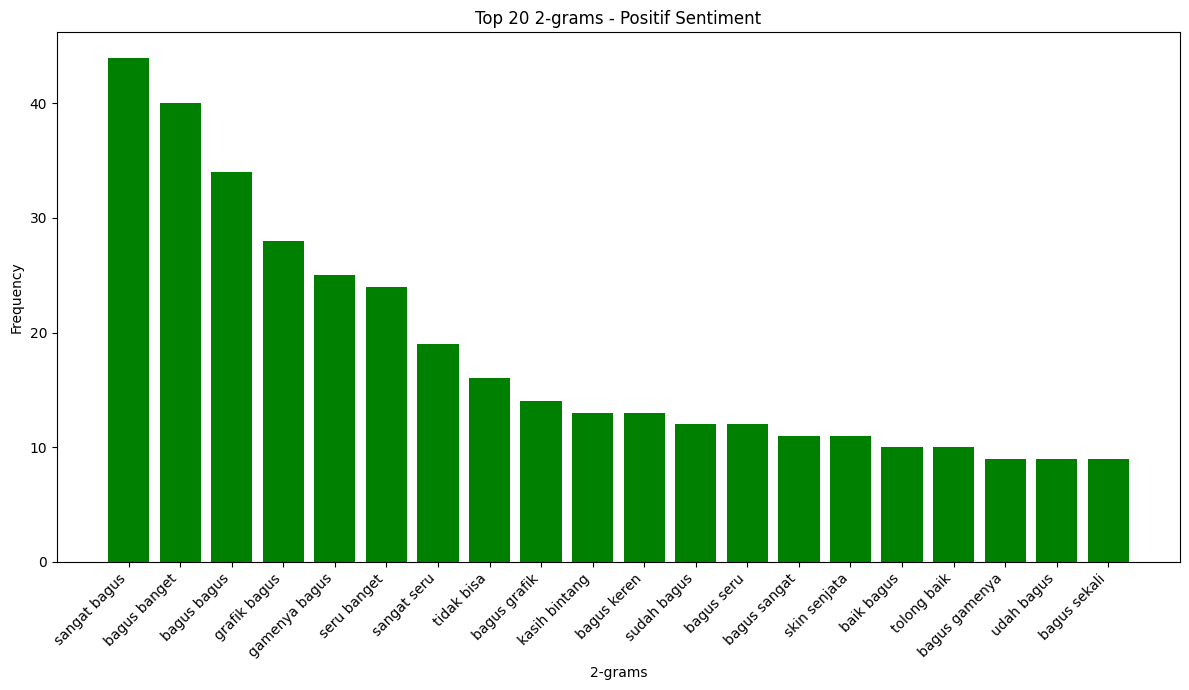

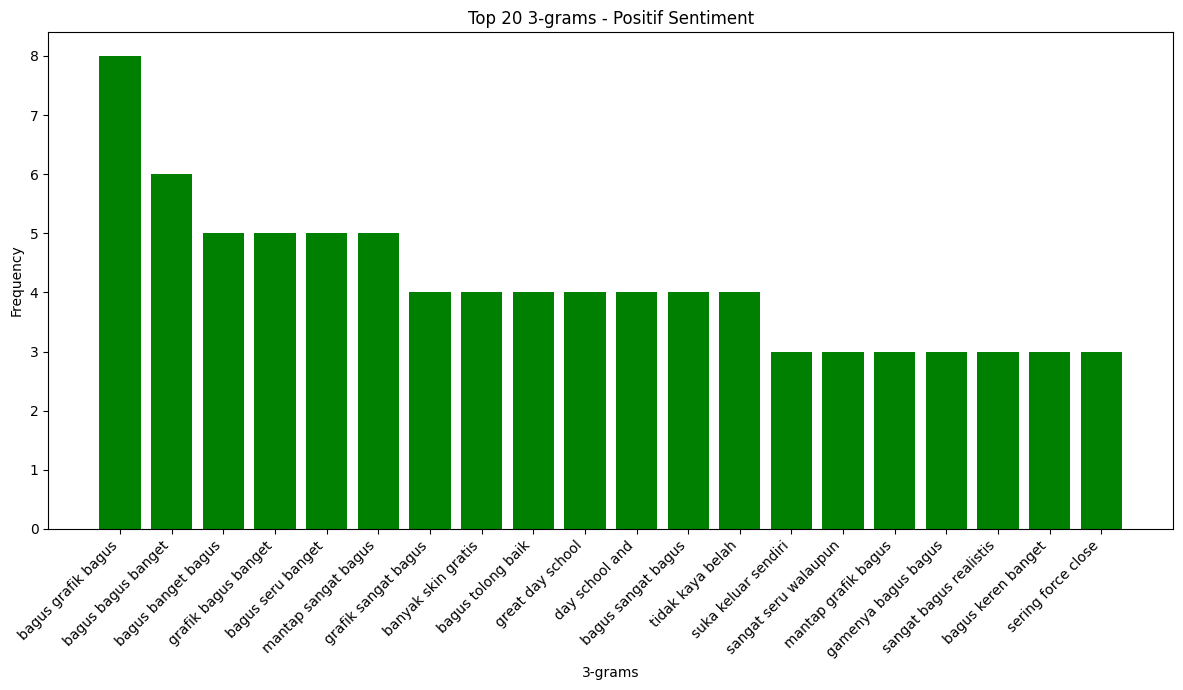

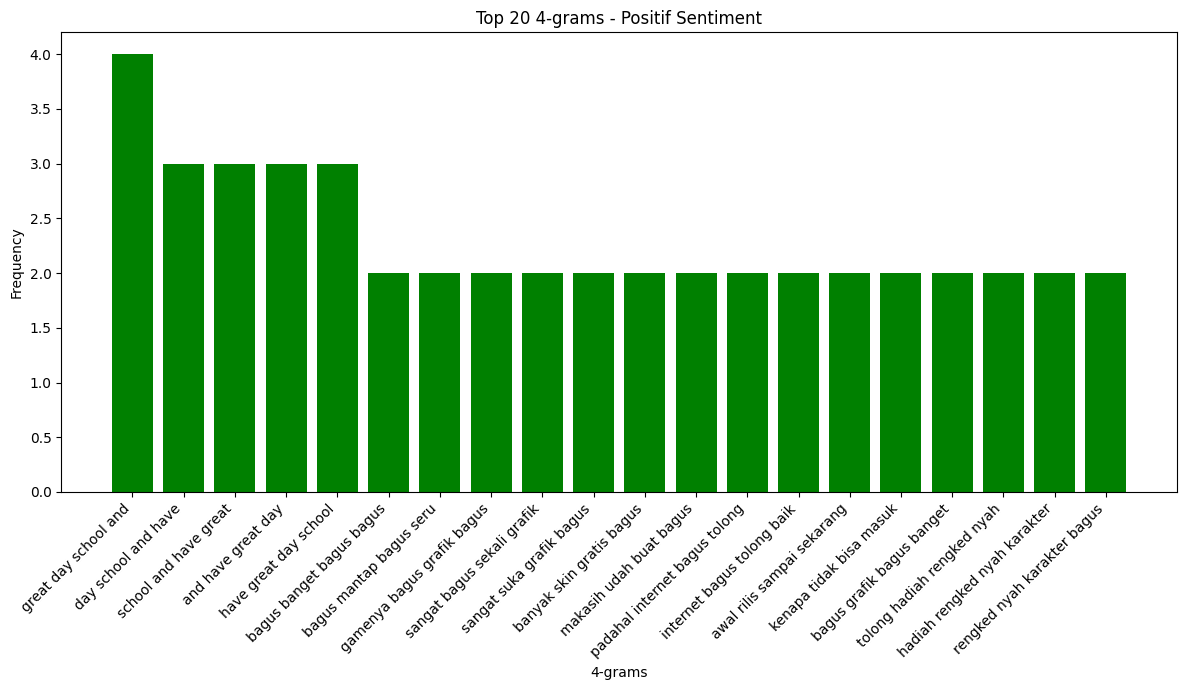

Generating plots for Neutral Sentiment...


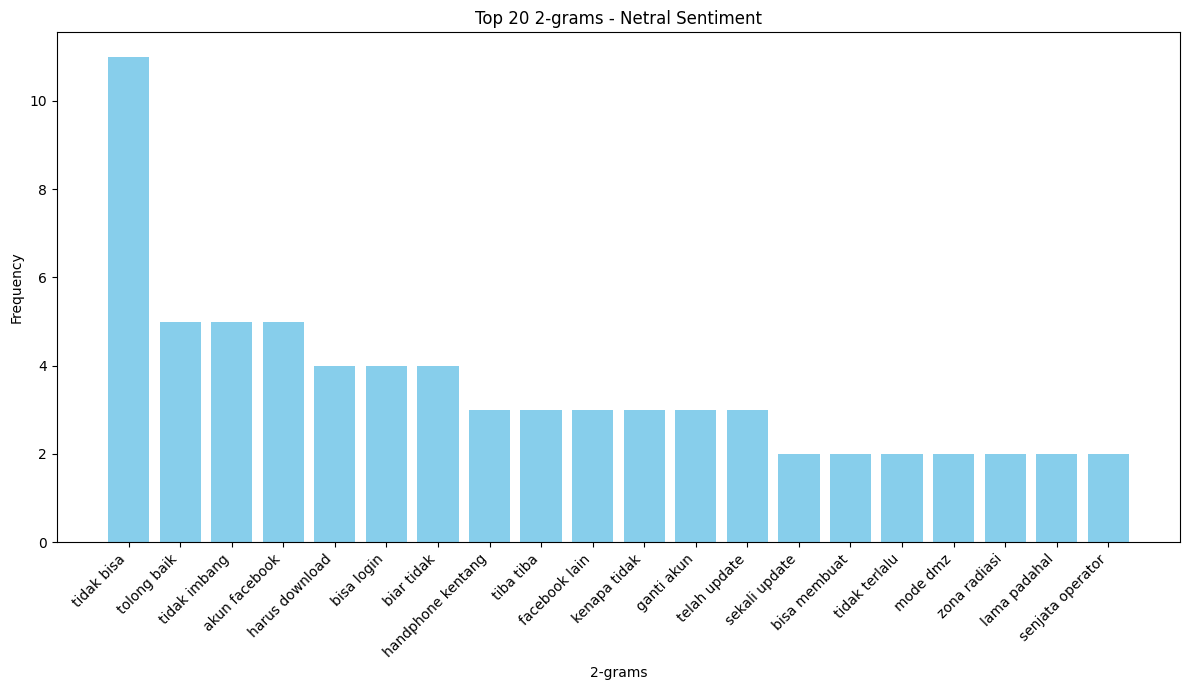

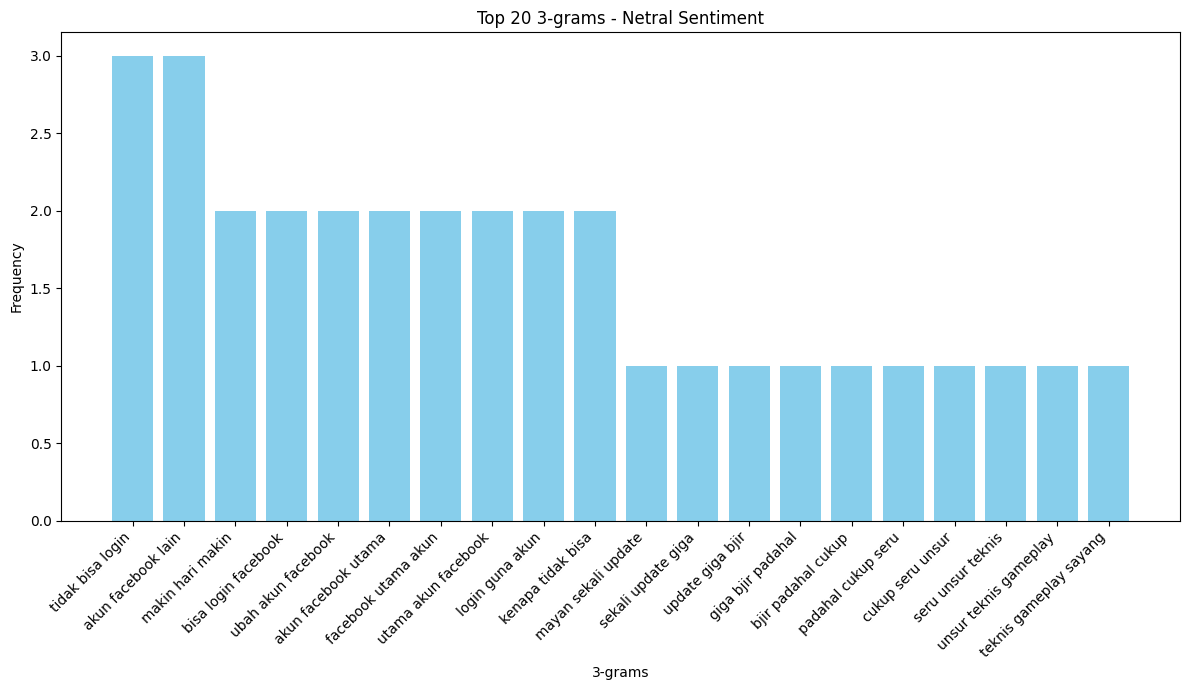

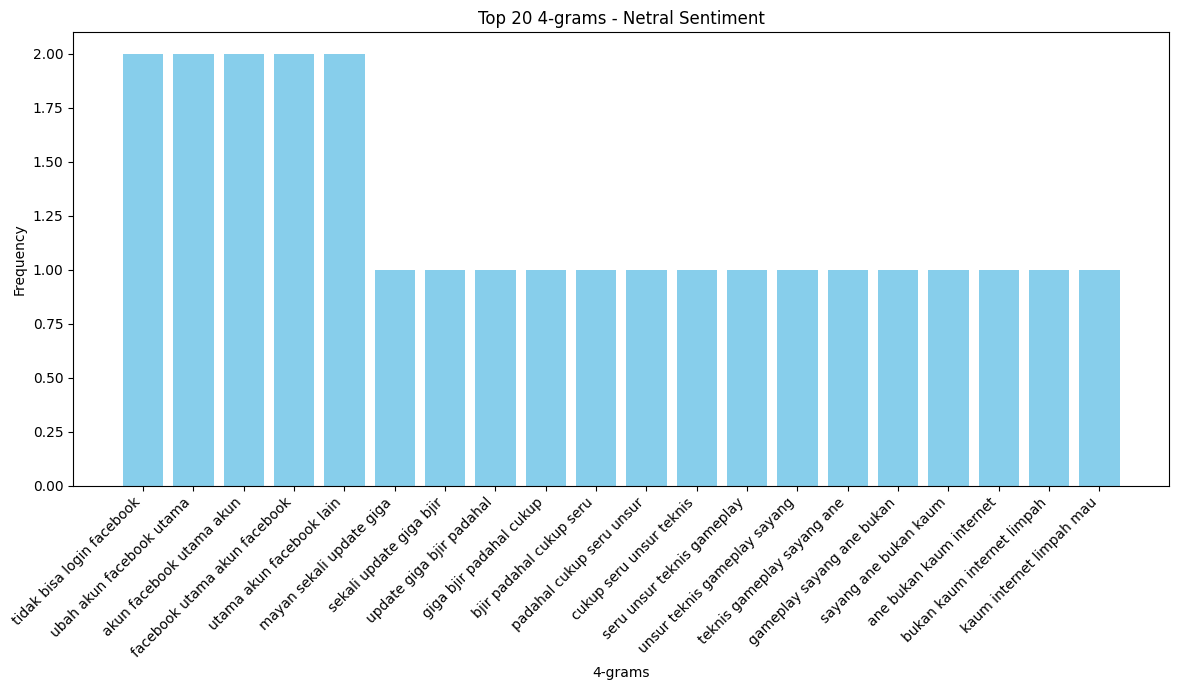

Generating plots for Negative Sentiment...


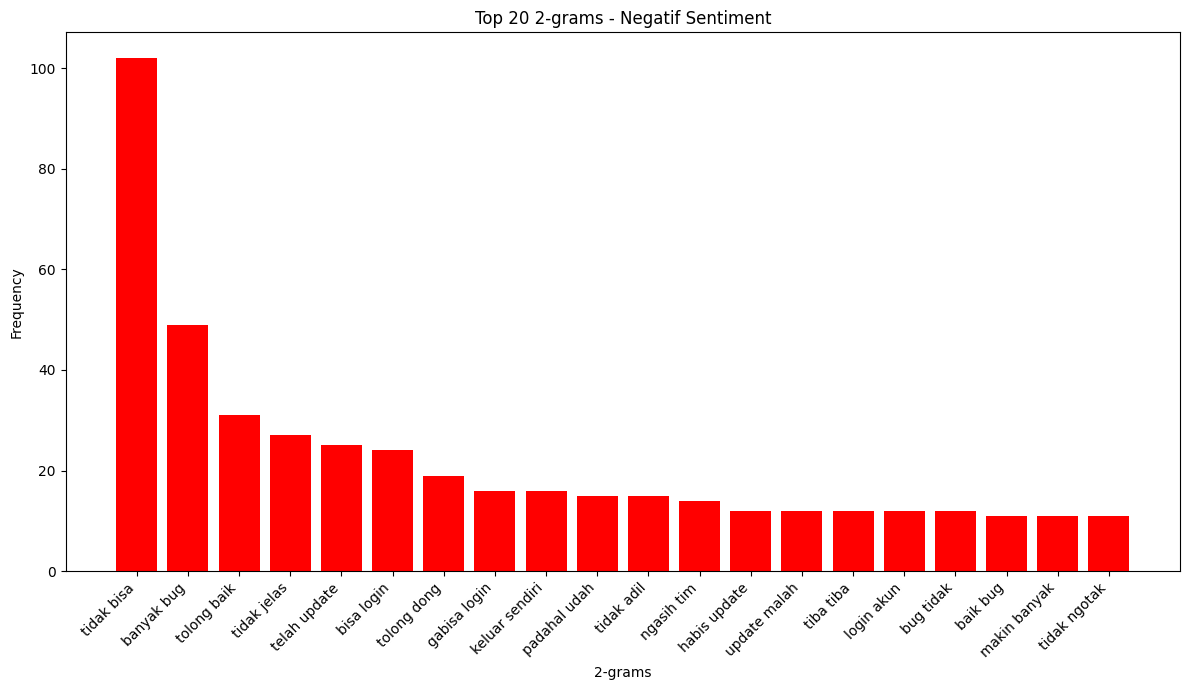

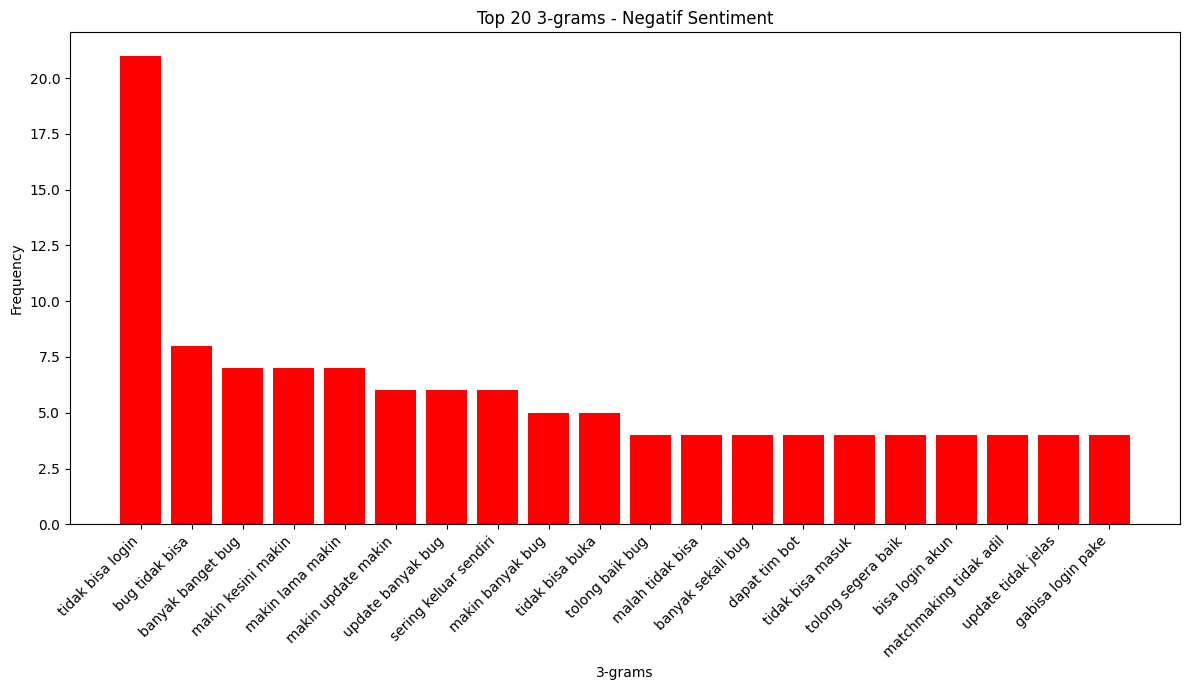

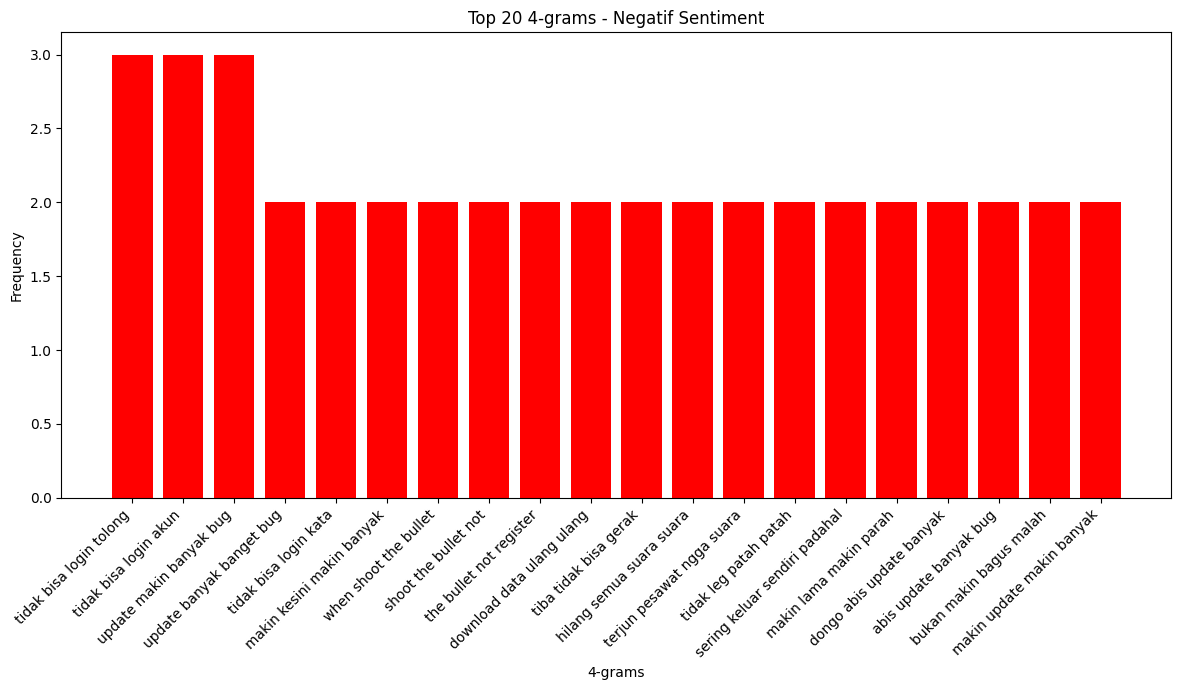

In [ ]:
import matplotlib.pyplot as plt
import collections

def plot_ngrams_by_sentiment(ngram_data, n_value, sentiment_label, color, top_n=20):
    """Plots the top N-grams for a given sentiment."""
    if not ngram_data:
        print(f"No {n_value}-grams to plot for {sentiment_label} sentiment.")
        return

    # Get the top N N-grams
    top_ngrams = ngram_data.most_common(top_n)

    # Prepare data for plotting
    words = [" ".join(ngram) for ngram, count in top_ngrams]
    counts = [count for ngram, count in top_ngrams]

    # Create the bar chart
    plt.figure(figsize=(12, 7))
    plt.bar(words, counts, color=color)
    plt.xlabel(f'{n_value}-grams')
    plt.ylabel('Frequency')
    plt.title(f'Top {top_n} {n_value}-grams - {sentiment_label.capitalize()} Sentiment')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# --- Plotting Positive Sentiment N-grams ---
print("Generating plots for Positive Sentiment...")
plot_ngrams_by_sentiment(positive_bigrams, 2, 'positif', 'green')
plot_ngrams_by_sentiment(positive_trigrams, 3, 'positif', 'green')
plot_ngrams_by_sentiment(positive_4grams, 4, 'positif', 'green')

# --- Plotting Neutral Sentiment N-grams ---
print("Generating plots for Neutral Sentiment...")
plot_ngrams_by_sentiment(neutral_bigrams, 2, 'netral', 'skyblue')
plot_ngrams_by_sentiment(neutral_trigrams, 3, 'netral', 'skyblue')
plot_ngrams_by_sentiment(neutral_4grams, 4, 'netral', 'skyblue')

# --- Plotting Negative Sentiment N-grams ---
print("Generating plots for Negative Sentiment...")
plot_ngrams_by_sentiment(negative_bigrams, 2, 'negatif', 'red')
plot_ngrams_by_sentiment(negative_trigrams, 3, 'negatif', 'red')
plot_ngrams_by_sentiment(negative_4grams, 4, 'negatif', 'red')


## Plot N-grams per sentiment

### Subtask:
Create bar charts to visualize the top N-grams for each sentiment, distinguishing them by sentiment in the plot titles and using appropriate colors.


## Summary:

### Data Analysis Key Findings
*   A custom function `generate_ngrams` was successfully defined to create n-grams from a list of words and count their frequencies.
*   The main DataFrame `df_cleaned` was filtered into three sentiment-specific DataFrames:
    *   Positive sentiment (`df_positive_cleaned`) contains 666 rows.
    *   Neutral sentiment (`df_neutral_cleaned`) contains 132 rows.
    *   Negative sentiment (`df_negative_cleaned`) contains 722 rows.
*   Bigrams, trigrams, and 4-grams were successfully generated and counted for each of the 'positif', 'netral', and 'negatif' sentiments, preparing the data for further analysis.

### Insights or Next Steps
*   The generated N-gram data for all sentiments and gram sizes (2, 3, and 4) is now ready to be used for visualization, specifically creating bar charts of the top N-grams as per the original subtask.
*   Analyzing the top N-grams for each sentiment will provide insights into common phrases and word combinations associated with positive, neutral, and negative expressions in the dataset.
